# Multi-basin Transfer Entropy (TE) - CAMELS (671 basins)

In this notebook, I will scale the Transfer Entropy workflow of all 671 CAMELS basins.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import random
from matplotlib.backends.backend_pdf import PdfPages
from PyPDF2 import PdfReader
import matplotlib.dates as mdates
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

# **Transfer Entropy Research (All 671 CAMELS Basins)**

In my previous research, I tested the workflow on 1 basin:
- Read forcing (Daymet) and streamflow (USGS)
- Clean the tables
- Merge by date
- Plot and analyze

In this notebook, I will use the **same workflow**, but for **all 671 basins**.


In [2]:
# Put main project folder here (this is the folder that contains my notebook)
PROJECT_DIR = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)")

# 2) Make clean output subfolders
OUT_ROOT    = PROJECT_DIR / "outputs"
MERGED_DIR  = OUT_ROOT / "merged_csv"
PDF_DIR     = OUT_ROOT / "pdf"
SUMMARY_DIR = OUT_ROOT / "summary_csv"
LOG_DIR     = OUT_ROOT / "logs"

for d in [OUT_ROOT, MERGED_DIR, PDF_DIR, SUMMARY_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR :", PROJECT_DIR)
print("OUT_ROOT    :", OUT_ROOT)
print("MERGED_DIR  :", MERGED_DIR)
print("PDF_DIR     :", PDF_DIR)
print("SUMMARY_DIR :", SUMMARY_DIR)
print("LOG_DIR     :", LOG_DIR)

PROJECT_DIR : C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)
OUT_ROOT    : C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs
MERGED_DIR  : C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\merged_csv
PDF_DIR     : C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf
SUMMARY_DIR : C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv
LOG_DIR    

## Read metadata (get all 671 basin IDs)

In [3]:
BASE_DIR = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research")

meta_file = list(BASE_DIR.rglob("camels_name.txt"))[0]
print("Using:", meta_file)

gauge_df = pd.read_csv(meta_file, sep=";", dtype=str)
gauge_df.columns = [c.strip() for c in gauge_df.columns]   # clean names

print("Total basins:", len(gauge_df))
print("Columns:", list(gauge_df.columns))
display(gauge_df.head(5))

Using: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\camels_name.txt
Total basins: 671
Columns: ['gauge_id', 'huc_02', 'gauge_name']


,gauge_id,huc_02,gauge_name
0,01013500,01,"Fish River near Fort Kent, Maine"
1,01022500,01,"Narraguagus River at Cherryfield, Maine"
2,01030500,01,"Mattawamkeag River near Mattawamkeag, Maine"
3,01031500,01,"Piscataquis River near Dover-Foxcroft, Maine"
4,01047000,01,"Carrabassett River near North Anson, Maine"


### Test 1 basin (read → clean → merge → save)

In [4]:
print("Columns are:", list(gauge_df.columns))

gauge_id = gauge_df.iloc[0]["gauge_id"]   # <-- FIXED (gauge_id)
huc02    = gauge_df.iloc[0]["huc_02"]

print("Testing basin:", gauge_id, "HUC:", huc02)

Columns are: ['gauge_id', 'huc_02', 'gauge_name']
Testing basin: 01013500 HUC: 01


In [5]:
FORCING_DIR = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\basin_timeseries_v1p2_metForcing_obsFlow\basin_dataset_public_v1p2\basin_mean_forcing\daymet")

Q_DIR = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\basin_timeseries_v1p2_metForcing_obsFlow\basin_dataset_public_v1p2\usgs_streamflow")

print("FORCING_DIR exists?", FORCING_DIR.exists())
print("Q_DIR exists?      ", Q_DIR.exists())

FORCING_DIR exists? True
Q_DIR exists?       True


#### show filenames for this one basin

In [6]:
print("huc02 =", huc02, "gauge_id =", gauge_id)

# List the HUC folders
print("\nFORCING HUC folder:", (FORCING_DIR / huc02))
print("Q HUC folder      :", (Q_DIR / huc02))

# Show matching files
forcing_matches = list((FORCING_DIR / huc02).glob(f"*{gauge_id}*"))
q_matches       = list((Q_DIR / huc02).glob(f"*{gauge_id}*"))

print("\nForcing matches:")
for f in forcing_matches[:10]:
    print(" -", f.name)

print("\nStreamflow matches:")
for f in q_matches[:10]:
    print(" -", f.name)

huc02 = 01 gauge_id = 01013500

FORCING HUC folder: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\basin_timeseries_v1p2_metForcing_obsFlow\basin_dataset_public_v1p2\basin_mean_forcing\daymet\01
Q HUC folder      : C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\basin_timeseries_v1p2_metForcing_obsFlow\basin_dataset_public_v1p2\usgs_streamflow\01

Forcing matches:
 - 01013500_lump_cida_forcing_leap.txt

Streamflow matches:
 - 01013500_streamflow_qc.txt


#### Read + clean + merge (1 basin) + save 1 merged CSV

In [7]:
forcing_file = FORCING_DIR / huc02 / f"{gauge_id}_lump_cida_forcing_leap.txt"
q_file       = Q_DIR       / huc02 / f"{gauge_id}_streamflow_qc.txt"

print("FORCING first 15 lines:")
with open(forcing_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(15):
        print(f"{i+1:02d}:", f.readline().rstrip())

print("\nSTREAMFLOW first 15 lines:")
with open(q_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(15):
        print(f"{i+1:02d}:", f.readline().rstrip())

FORCING first 15 lines:
01:   46.84
02:  353.00
03: 2260093113
04: Year Mnth Day Hr dayl(s) prcp(mm/day) srad(W/m2) swe(mm) tmax(C) tmin(C) vp(Pa)
05: 1980 01 01 12	30172.51	0.00	153.40	0.00	-6.54	-16.30	171.69
06: 1980 01 02 12	30253.10	0.00	145.27	0.00	-6.18	-15.22	185.94
07: 1980 01 03 12	30344.18	0.00	146.96	0.00	-9.89	-18.86	138.39
08: 1980 01 04 12	30408.33	0.00	146.20	0.00	-10.98	-19.76	120.06
09: 1980 01 05 12	30413.48	0.00	170.43	0.00	-11.29	-22.21	117.87
10: 1980 01 06 12	30485.93	0.00	188.17	0.00	-11.80	-24.68	80.00
11: 1980 01 07 12	30598.72	6.69	170.30	0.00	-4.46	-23.73	80.00
12: 1980 01 08 12	30733.73	3.64	120.17	0.00	-2.78	-12.30	240.07
13: 1980 01 09 12	30758.40	0.00	170.71	0.00	-7.00	-17.41	159.10
14: 1980 01 10 12	30798.52	0.00	215.69	0.00	-9.80	-26.40	80.00
15: 1980 01 11 12	30944.32	4.96	178.83	0.00	3.69	-24.73	80.00

STREAMFLOW first 15 lines:
01: 01013500 1980 01 01   655.00 A
02: 01013500 1980 01 02   640.00 A
03: 01013500 1980 01 03   625.00 A
04: 01013500 1980 

In [8]:
forcing_file = FORCING_DIR / huc02 / f"{gauge_id}_lump_cida_forcing_leap.txt"
q_file       = Q_DIR / huc02 / f"{gauge_id}_streamflow_qc.txt"

# read forcing (skip first 4 lines, no header)
forcing_df = pd.read_csv(forcing_file, sep=r"\s+", skiprows=4, header=None)
forcing_df.columns = ["Year","Mnth","Day","Hr","dayl","prcp","srad","swe","tmax","tmin","vp"]

# date
forcing_df["date"] = pd.to_datetime(dict(year=forcing_df["Year"], month=forcing_df["Mnth"], day=forcing_df["Day"]))
forcing_df = forcing_df[["date","prcp","srad","tmax","tmin","vp"]].copy()

# read streamflow (no header)
q_df = pd.read_csv(q_file, sep=r"\s+", header=None)
q_df.columns = ["gage_id","Year","Mnth","Day","Q","flag"]

# date
q_df["date"] = pd.to_datetime(dict(year=q_df["Year"], month=q_df["Mnth"], day=q_df["Day"]))
q_df = q_df[["date","Q"]].copy()

# merge + save (NO row dropping)
merged_df = pd.merge(forcing_df, q_df, on="date", how="inner")

print("Merged rows:", len(merged_df))
display(merged_df.head(5))

out_path = MERGED_DIR / f"{gauge_id}_merged_forcing_q.csv"
merged_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Merged rows: 12784


,date,prcp,srad,tmax,tmin,vp,Q
0,1980-01-01,0.0,153.40,-6.54,-16.30,171.69,655.0
1,1980-01-02,0.0,145.27,-6.18,-15.22,185.94,640.0
2,1980-01-03,0.0,146.96,-9.89,-18.86,138.39,625.0
3,1980-01-04,0.0,146.20,-10.98,-19.76,120.06,620.0
4,1980-01-05,0.0,170.43,-11.29,-22.21,117.87,605.0


Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\merged_csv\01013500_merged_forcing_q.csv


## Merge all 671 basins (save 671 CSV + 1 log)

In [9]:
log = []

for i in range(len(gauge_df)):
    gauge_id = gauge_df.loc[i, "gauge_id"]
    huc02    = gauge_df.loc[i, "huc_02"]

    forcing_file = FORCING_DIR / huc02 / f"{gauge_id}_lump_cida_forcing_leap.txt"
    q_file       = Q_DIR / huc02 / f"{gauge_id}_streamflow_qc.txt"

    try:
        # read forcing
        forcing_df = pd.read_csv(forcing_file, sep=r"\s+", skiprows=4, header=None)
        forcing_df.columns = ["Year","Mnth","Day","Hr","dayl","prcp","srad","swe","tmax","tmin","vp"]
        forcing_df["date"] = pd.to_datetime(dict(year=forcing_df.iloc[:,0], month=forcing_df.iloc[:,1], day=forcing_df.iloc[:,2]))
        forcing_df = forcing_df[["date","prcp","srad","tmax","tmin","vp"]].copy()

        # read streamflow
        q_df = pd.read_csv(q_file, sep=r"\s+", header=None)
        q_df.columns = ["gage_id","Year","Mnth","Day","Q","flag"]
        q_df["date"] = pd.to_datetime(dict(year=q_df.iloc[:,1], month=q_df.iloc[:,2], day=q_df.iloc[:,3]))
        q_df = q_df[["date","Q"]].copy()

        # merge (NO row dropping)
        merged_df = pd.merge(forcing_df, q_df, on="date", how="inner")

        # save merged
        out_path = MERGED_DIR / f"{gauge_id}_merged_forcing_q.csv"
        merged_df.to_csv(out_path, index=False)

        log.append([gauge_id, huc02, "OK", len(merged_df), str(out_path)])

    except Exception as e:
        log.append([gauge_id, huc02, "FAIL", np.nan, str(e)])

# save log
log_df = pd.DataFrame(log, columns=["gauge_id","huc_02","status","n_rows","info"])
log_path = LOG_DIR / "merge_log_all_basins.csv"
log_df.to_csv(log_path, index=False)

print("Done merging all basins.")
print("Saved log:", log_path)
print(log_df["status"].value_counts())

Done merging all basins.
Saved log: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\logs\merge_log_all_basins.csv
status
OK    671
Name: count, dtype: int64


### Update all 671 merged files (add Tair, drop tmax/tmin) and rename all colummns name

In [10]:
# input folder (current old merged files)
IN_DIR = OUT_ROOT / "merged_csv"

# output folder = SAME folder (replace files)
UPDATED_DIR = OUT_ROOT / "merged_csv"

count = 0

for csv_file in IN_DIR.glob("*_merged_forcing_q.csv"):
    df = pd.read_csv(csv_file, parse_dates=["date"])

    # make Tair
    df["Tair"] = (df["tmax"] + df["tmin"]) / 2.0

    # keep only what we want
    df2 = df[["date", "prcp", "srad", "Tair", "vp", "Q"]].copy()

    # rename columns
    df2.columns = ["Date", "PRCP", "SRAD", "Tair", "VP", "Q"]

    # save with same filename (this replaces the old file)
    df2.to_csv(csv_file, index=False)

    count += 1

print("Replaced files:", count)
print("Saved in:", UPDATED_DIR)

Replaced files: 671
Saved in: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\merged_csv


## **Time-series PDF for all 671 basins (2-year custom range)**

In [11]:
# Two_Years Time series
USE_CUSTOM_DATES = True
CUSTOM_START = "2000-01-01"
CUSTOM_END   = "2001-12-31"

# Input folder
IN_DIR = OUT_ROOT / "merged_csv"

# Outputs
pdf_path    = PDF_DIR / "TimeSeries_All671.pdf"
summary_csv = SUMMARY_DIR / "TimeSeries_DateRanges_All671.csv"

summary = []
pages_saved = 0

with PdfPages(pdf_path) as pdf:

    for i, row in gauge_df.iterrows():

        gauge_id   = str(row["gauge_id"]).zfill(8)
        huc02      = str(row["huc_02"]).zfill(2)
        basin_name = str(row["gauge_name"])

        csv_path = IN_DIR / f"{gauge_id}_merged_forcing_q.csv"

        try:
            # read basin file
            df = pd.read_csv(csv_path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

            # mark invalid Q as missing (do NOT drop rows)
            df["Q"] = pd.to_numeric(df["Q"], errors="coerce")
            df.loc[df["Q"] == -999, "Q"] = np.nan

            # choose date window
            if USE_CUSTOM_DATES:
                start_date = pd.to_datetime(CUSTOM_START)
                end_date   = pd.to_datetime(CUSTOM_END)
            else:
                start_date = df["Date"].min()
                end_date   = df["Date"].max()

            df2 = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

            # CASE A: NO DATA in window -> placeholder page
            if len(df2) == 0:
                fig = plt.figure(figsize=(12, 6))
                plt.axis("off")
                plt.title(f"Basin {gauge_id} (HUC {huc02}) — {basin_name}", fontsize=12)
                plt.text(
                    0.5, 0.5,
                    f"NO DATA in selected window\n{start_date.date()} to {end_date.date()}",
                    ha="center", va="center", fontsize=14
                )
                pdf.savefig(fig)
                plt.close(fig)

                pages_saved += 1
                summary.append([gauge_id, huc02, start_date, end_date, 0, "NO DATA"])
                continue

            # CASE B: OK -> plot 5 panels
            summary.append([gauge_id, huc02, df2["Date"].min(), df2["Date"].max(), len(df2), "OK"])

            fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

            major = mdates.MonthLocator(interval=2)
            minor = mdates.MonthLocator(interval=1)
            fmt   = mdates.DateFormatter("%Y-%m")

            for ax in axes:
                ax.xaxis.set_major_locator(major)
                ax.xaxis.set_minor_locator(minor)
                ax.xaxis.set_major_formatter(fmt)
                ax.grid(True, which="major", linewidth=0.4, alpha=0.35)
                ax.grid(True, which="minor", linewidth=0.2, alpha=0.20)

            axes[0].plot(df2["Date"], df2["PRCP"], linewidth=0.8)
            axes[0].set_ylabel("PRCP\n(mm/day)")
            axes[0].set_title(f"Basin {gauge_id} (HUC {huc02}) — {basin_name}")

            axes[1].plot(df2["Date"], df2["SRAD"], linewidth=0.8)
            axes[1].set_ylabel("SRAD\n(W/m²)")

            axes[2].plot(df2["Date"], df2["Tair"], linewidth=0.8)
            axes[2].set_ylabel("Tair\n(°C)")

            axes[3].plot(df2["Date"], df2["VP"], linewidth=0.8)
            axes[3].set_ylabel("VP\n(Pa)")

            axes[4].plot(df2["Date"], df2["Q"], linewidth=0.8)
            axes[4].set_ylabel("Q")
            axes[4].set_xlabel("Date")

            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

            pages_saved += 1

        except Exception as e:
            fig = plt.figure(figsize=(12, 6))
            plt.axis("off")
            plt.title(f"Basin {gauge_id} (HUC {huc02}) — {basin_name}", fontsize=12)
            plt.text(
                0.5, 0.5,
                f"ERROR reading/plotting this basin\n{type(e).__name__}: {str(e)}",
                ha="center", va="center", fontsize=10
            )
            pdf.savefig(fig)
            plt.close(fig)

            pages_saved += 1
            summary.append([gauge_id, huc02, None, None, 0, f"ERROR: {type(e).__name__}"])

summary_df = pd.DataFrame(summary, columns=["gauge_id", "huc_02", "plot_start", "plot_end", "n_points", "status"])
summary_df.to_csv(summary_csv, index=False)

print("Saved PDF:", pdf_path)
print("Saved summary CSV:", summary_csv)
print("Pages saved (should be 671):", pages_saved)
print(summary_df["status"].value_counts())

reader = PdfReader(str(pdf_path))
print("Pages in PDF (PyPDF2):", len(reader.pages))

Saved PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf\TimeSeries_All671.pdf
Saved summary CSV: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\TimeSeries_DateRanges_All671.csv
Pages saved (should be 671): 671
status
OK    671
Name: count, dtype: int64
Pages in PDF (PyPDF2): 671


### **Time-series (No Custom Time)**

In [12]:
# ALL Time series
USE_CUSTOM_DATES = False
CUSTOM_START = "2000-01-01"
CUSTOM_END   = "2001-12-31"

# Input folder
IN_DIR = OUT_ROOT / "merged_csv"

# Outputs
pdf_path    = PDF_DIR / "TimeSeries_AllYEAR_All671.pdf"
summary_csv = SUMMARY_DIR / "TimeSeries_DateRanges_AllYEAR_All671.csv"

summary = []
pages_saved = 0

with PdfPages(pdf_path) as pdf:

    for i, row in gauge_df.iterrows():

        gauge_id   = str(row["gauge_id"]).zfill(8)
        huc02      = str(row["huc_02"]).zfill(2)
        basin_name = str(row["gauge_name"])

        csv_path = IN_DIR / f"{gauge_id}_merged_forcing_q.csv"

        try:
            # read basin file
            df = pd.read_csv(csv_path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

            # mark invalid Q as missing (do NOT drop rows)
            df["Q"] = pd.to_numeric(df["Q"], errors="coerce")
            df.loc[df["Q"] == -999, "Q"] = np.nan

            # choose date window
            if USE_CUSTOM_DATES:
                start_date = pd.to_datetime(CUSTOM_START)
                end_date   = pd.to_datetime(CUSTOM_END)
            else:
                start_date = df["Date"].min()
                end_date   = df["Date"].max()

            df2 = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

            # CASE A: NO DATA in window -> placeholder page
            if len(df2) == 0:
                fig = plt.figure(figsize=(12, 6))
                plt.axis("off")
                plt.title(f"Basin {gauge_id} (HUC {huc02}) — {basin_name}", fontsize=12)
                plt.text(
                    0.5, 0.5,
                    f"NO DATA in selected window\n{start_date.date()} to {end_date.date()}",
                    ha="center", va="center", fontsize=14
                )
                pdf.savefig(fig)
                plt.close(fig)

                pages_saved += 1
                summary.append([gauge_id, huc02, start_date, end_date, 0, "NO DATA"])
                continue

            # CASE B: OK -> plot 5 panels
            summary.append([gauge_id, huc02, df2["Date"].min(), df2["Date"].max(), len(df2), "OK"])

            fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

            major = mdates.MonthLocator(interval=2)
            minor = mdates.MonthLocator(interval=1)
            fmt   = mdates.DateFormatter("%Y-%m")

            for ax in axes:
                ax.xaxis.set_major_locator(major)
                ax.xaxis.set_minor_locator(minor)
                ax.xaxis.set_major_formatter(fmt)
                ax.grid(True, which="major", linewidth=0.4, alpha=0.35)
                ax.grid(True, which="minor", linewidth=0.2, alpha=0.20)

            axes[0].plot(df2["Date"], df2["PRCP"], linewidth=0.8)
            axes[0].set_ylabel("PRCP\n(mm/day)")
            axes[0].set_title(f"Basin {gauge_id} (HUC {huc02}) — {basin_name}")

            axes[1].plot(df2["Date"], df2["SRAD"], linewidth=0.8)
            axes[1].set_ylabel("SRAD\n(W/m²)")

            axes[2].plot(df2["Date"], df2["Tair"], linewidth=0.8)
            axes[2].set_ylabel("Tair\n(°C)")

            axes[3].plot(df2["Date"], df2["VP"], linewidth=0.8)
            axes[3].set_ylabel("VP\n(Pa)")

            axes[4].plot(df2["Date"], df2["Q"], linewidth=0.8)
            axes[4].set_ylabel("Q")
            axes[4].set_xlabel("Date")

            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

            pages_saved += 1

        except Exception as e:
            fig = plt.figure(figsize=(12, 6))
            plt.axis("off")
            plt.title(f"Basin {gauge_id} (HUC {huc02}) — {basin_name}", fontsize=12)
            plt.text(
                0.5, 0.5,
                f"ERROR reading/plotting this basin\n{type(e).__name__}: {str(e)}",
                ha="center", va="center", fontsize=10
            )
            pdf.savefig(fig)
            plt.close(fig)

            pages_saved += 1
            summary.append([gauge_id, huc02, None, None, 0, f"ERROR: {type(e).__name__}"])

summary_df = pd.DataFrame(summary, columns=["gauge_id", "huc_02", "plot_start", "plot_end", "n_points", "status"])
summary_df.to_csv(summary_csv, index=False)

print("Saved PDF:", pdf_path)
print("Saved summary CSV:", summary_csv)
print("Pages saved (should be 671):", pages_saved)
print(summary_df["status"].value_counts())

reader = PdfReader(str(pdf_path))
print("Pages in PDF (PyPDF2):", len(reader.pages))

Saved PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf\TimeSeries_AllYEAR_All671.pdf
Saved summary CSV: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\TimeSeries_DateRanges_AllYEAR_All671.csv
Pages saved (should be 671): 671
status
OK    671
Name: count, dtype: int64
Pages in PDF (PyPDF2): 671


In [13]:
print("Total basins in metadata:", len(gauge_df))
print("Plotted basins (OK):", (summary_df["status"] == "OK").sum())
print("No-data basins:", (summary_df["status"] == "NO DATA").sum())

display(summary_df[summary_df["status"] == "NO DATA"].head(30))

Total basins in metadata: 671
Plotted basins (OK): 671
No-data basins: 0


,gauge_id,huc_02,plot_start,plot_end,n_points,status


## **Diagnostic check using probability distributions (binning)**

In this step, we check how each variable is distributed **before** computing Transfer Entropy.  
This is important because TE is computed after **discretizing (binning)** the continuous data, so we want to confirm the binning makes sense.

For **each basin (all 671 basins)**, we:

1. Load the merged daily dataset (PRCP, SRAD, Tair, VP, Q)
2. Select the **same time window**  
3. Plot histograms (probability distribution shapes) for each variable:
   - **PRCP:** special binning with **1 bin for zero precipitation** and **4 equal-width bins for PRCP > 0**
   - **SRAD, Tair, VP, Q:** **equal-width binning with Nb = 5**
4. Put all distributions for one basin into **one figure** (multiple panels)
5. Save all basin figures together into **one PDF** (671 pages, one page per basin)

This diagnostic step helps confirm that:
- precipitation has many zeros (so a zero-bin is necessary)
- other variables are reasonably covered by equal-width bins
- the chosen bin setup is consistent across basins and ready for TE computation


In [14]:
ranges = []

for i, row in gauge_df.iterrows():

    gauge_id   = str(row["gauge_id"]).zfill(8)
    huc02      = row["huc_02"]
    gauge_name = row["gauge_name"]

    csv_path = (OUT_ROOT / "merged_csv") / f"{gauge_id}_merged_forcing_q.csv"
    df = pd.read_csv(csv_path, parse_dates=["Date"])

    # mark invalid Q as missing (no row dropping)
    df["Q"] = pd.to_numeric(df["Q"], errors="coerce")
    df.loc[df["Q"] == -999, "Q"] = np.nan

    ranges.append([gauge_id, huc02, df["Date"].min(), df["Date"].max(), len(df)])

ranges_df = pd.DataFrame(ranges, columns=["gauge_id", "huc_02", "data_start", "data_end", "n_rows"])

out_path = SUMMARY_DIR / "AllBasins_DataDateRanges.csv"
ranges_df.to_csv(out_path, index=False)

print("Saved:", out_path)
display(ranges_df.head())

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\AllBasins_DataDateRanges.csv


,gauge_id,huc_02,data_start,data_end,n_rows
0,01013500,01,1980-01-01,2014-12-31,12784
1,01022500,01,1980-01-01,2014-12-31,12784
2,01030500,01,1980-01-01,2014-12-31,12784
3,01031500,01,1980-01-01,2014-12-31,12784
4,01047000,01,1980-01-01,2014-12-31,12784


In [15]:
USE_CUSTOM_DATES = False
CUSTOM_START = "1985-01-01"
CUSTOM_END   = "2010-12-31"

NB = 5  # bins for SRAD, Tair, VP, Q (equal-width)

pdf_path    = PDF_DIR / "Probability_Distributions_All671.pdf"
summary_csv = SUMMARY_DIR / "Probability_Distributions_Summary.csv"

summary = []

# Helpers
def prcp_special_bins_exact(prcp_series, nb_total=5):
    prcp = prcp_series.dropna().values
    prcp_pos = prcp[prcp > 0]

    if len(prcp_pos) == 0:
        edges_pos = np.linspace(1e-6, 1.0, nb_total)
    else:
        xmin = prcp_pos.min()
        xmax = prcp_pos.max()
        edges_pos = np.linspace(xmin, xmax, nb_total)

    edges = np.concatenate(([-1e-6, 1e-6], edges_pos[1:]))  # length 6
    return edges

def equal_width_edges(series, nb=5):
    x = series.dropna().values
    if len(x) == 0:
        return np.array([0.0, 1.0])

    xmin = float(np.min(x))
    xmax = float(np.max(x))

    if xmin == xmax:
        return np.array([xmin - 0.2, xmax + 0.2])

    return np.linspace(xmin, xmax, nb + 1)

def hist_counts_probs(values, edges):
    counts, _ = np.histogram(values, bins=edges)
    total = counts.sum()
    probs = counts / total if total > 0 else np.zeros_like(counts, dtype=float)
    return counts, probs

def bin_centers(edges):
    return 0.5 * (edges[:-1] + edges[1:])

def info_text(varname, values, edges, counts, probs,
              precision_edges=4, precision_probs=6, precision_minmax=4):
    edges_str = np.array2string(edges, precision=precision_edges, separator=', ')
    probs_round = np.round(probs, precision_probs)

    if len(values) > 0:
        vmin = float(np.min(values))
        vmax = float(np.max(values))
    else:
        vmin, vmax = np.nan, np.nan

    return (
        f"Bin edges: {edges_str}\n"
        f"Counts: {counts.tolist()}\n"
        f"Probabilities: {probs_round.tolist()}\n"
        f"Min_{varname}: {vmin:.{precision_minmax}f}\n"
        f"Max_{varname}: {vmax:.{precision_minmax}f}"
    )

def plot_prob_bar(ax, values, edges, title, xlabel, varname):
    counts, probs = hist_counts_probs(values, edges)
    centers = bin_centers(edges)
    widths = np.diff(edges)

    ax.bar(centers, probs, width=widths, align="center", edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability")
    ax.grid(True, alpha=0.3)

    ax.text(
        0.99, 0.99,
        info_text(varname, values, edges, counts, probs),
        transform=ax.transAxes,
        fontsize=8,
        va="top",
        ha="right"
    )

# Main loop -> 671 pages PDF
with PdfPages(pdf_path) as pdf:

    for i, row in gauge_df.iterrows():

        gauge_id   = str(row["gauge_id"]).zfill(8)
        huc02      = row["huc_02"]
        basin_name = row["gauge_name"]

        csv_path = (OUT_ROOT / "merged_csv") / f"{gauge_id}_merged_forcing_q.csv"
        df = pd.read_csv(csv_path, parse_dates=["Date"])

        # mark invalid Q as missing (no row dropping)
        df["Q"] = pd.to_numeric(df["Q"], errors="coerce")
        df.loc[df["Q"] == -999, "Q"] = np.nan

        # Choose date window
        if USE_CUSTOM_DATES:
            start_date = pd.to_datetime(CUSTOM_START)
            end_date   = pd.to_datetime(CUSTOM_END)
        else:
            start_date = df["Date"].min()
            end_date   = df["Date"].max()

        df2 = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

        if len(df2) == 0:
            summary.append([gauge_id, huc02, basin_name, start_date, end_date, 0, "NO DATA"])
            continue

        prcp = df2["PRCP"].dropna().values
        srad = df2["SRAD"].dropna().values
        tair = df2["Tair"].dropna().values
        vp   = df2["VP"].dropna().values
        q    = df2["Q"].dropna().values

        prcp_edges = prcp_special_bins_exact(pd.Series(prcp), nb_total=5)
        srad_edges = equal_width_edges(pd.Series(srad), nb=NB)
        tair_edges = equal_width_edges(pd.Series(tair), nb=NB)
        vp_edges   = equal_width_edges(pd.Series(vp), nb=NB)
        q_edges    = equal_width_edges(pd.Series(q), nb=NB)

        fig, axes = plt.subplots(5, 1, figsize=(11, 14))
        fig.suptitle(
            f"Probability Distributions — Basin {gauge_id} (HUC {huc02}) — {basin_name}\n"
            f"Window: {df2['Date'].min().date()} to {df2['Date'].max().date()}",
            y=0.995
        )

        plot_prob_bar(axes[0], prcp, prcp_edges,
                      "PRCP Probability Distribution (1 zero-bin + 4 bins for PRCP > 0)",
                      "Precipitation (mm/day)", "PRCP")

        plot_prob_bar(axes[1], srad, srad_edges,
                      f"SRAD Probability Distribution (equal-width bins = {NB})",
                      "SRAD (W/m²)", "SRAD")

        plot_prob_bar(axes[2], tair, tair_edges,
                      f"Tair Probability Distribution (equal-width bins = {NB})",
                      "Tair (°C)", "Tair")

        plot_prob_bar(axes[3], vp, vp_edges,
                      f"VP Probability Distribution (equal-width bins = {NB})",
                      "VP (Pa)", "VP")

        plot_prob_bar(axes[4], q, q_edges,
                      f"Streamflow Q Probability Distribution (equal-width bins = {NB})",
                      "Q", "Q")

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        pdf.savefig(fig)
        plt.close(fig)

        summary.append([gauge_id, huc02, basin_name, df2["Date"].min(), df2["Date"].max(), len(df2), "OK"])

print("Saved PDF:", pdf_path)

summary_df = pd.DataFrame(summary, columns=["gauge_id","huc_02","gauge_name","plot_start","plot_end","n_points","status"])
summary_df.to_csv(summary_csv, index=False)

print("Saved summary CSV:", summary_csv)
display(summary_df.head())

Saved PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf\Probability_Distributions_All671.pdf
Saved summary CSV: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\Probability_Distributions_Summary.csv


,gauge_id,huc_02,gauge_name,plot_start,plot_end,n_points,status
0,01013500,01,"Fish River near Fort Kent, Maine",1980-01-01,2014-12-31,12784,OK
1,01022500,01,"Narraguagus River at Cherryfield, Maine",1980-01-01,2014-12-31,12784,OK
2,01030500,01,"Mattawamkeag River near Mattawamkeag, Maine",1980-01-01,2014-12-31,12784,OK
3,01031500,01,"Piscataquis River near Dover-Foxcroft, Maine",1980-01-01,2014-12-31,12784,OK
4,01047000,01,"Carrabassett River near North Anson, Maine",1980-01-01,2014-12-31,12784,OK


In [16]:
print(pdf_path)
print(summary_csv)
print(summary_df["status"].value_counts())

C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf\Probability_Distributions_All671.pdf
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\Probability_Distributions_Summary.csv
status
OK    671
Name: count, dtype: int64


## **Transfer Entropy (TE) computation with updated PRCP binning**

Now we compute Transfer Entropy from each atmospheric forcing (PRCP, SRAD, Tair, VP) to streamflow (Q) for lags τ = 1 to 30 days.

The workflow is the same as before. The only change is:
- When the source variable is PRCP, we use the special PRCP bin edges (`prcp_edges`) for the source dimension in TE.
- For other variables, we keep equal-width binning with Nb = 5.


In [17]:
def te_bins_for(source_name, nbin):
    # TE data columns inside transfer_entropy are:
    # [ y(t), x(t-lag), y(t-1) ]
    if source_name == "PRCP":
        return [nbin, prcp_edges, nbin]  # PRCP is x(t-lag) = middle column
    else:
        return [nbin, nbin, nbin]


## Transfer Entropy (PRCP → Q, SRAD → Q, Tair → Q, and VP → Q)

In [18]:
class INFO(object):
    """
    A unified class that combines data handling (histogramming) and all 
    information-theoretic metrics (Entropy, MI, CMI/TE). This consolidates 
    the functionality of the original INFO1, INFO2, and the separate computeCMI 
    function into a single class.
    """

    def __init__(self, data, bins, ranges=None, weights=None, base=np.e):
        """
        Initializes the analyzer by converting raw data points into a Joint 
        Probability Distribution Function (PDF) via a histogram. (Original INFO2 init)
        
        data -- the data to be histogrammed [numpy (N, D) array or DataFrame values]
        bins -- the bin specification
        ranges -- optional bin ranges
        weights -- optional sample weights
        base -- the logarithm base
        """
        self.base = base
        
        if isinstance(data, pd.DataFrame):
            data = data.values
            
        self.data = data
        self.bins = bins
        self.ranges = ranges
        
        # Remove any nan sample
        data = data[~np.isnan(data).any(axis=1)]

        # N: number of datapoints, D: number of dimensions
        self.N, self.D = data.shape

        # Count the histogram density
        pdf, self.edges = np.histogramdd(data, bins=bins, range=ranges, 
                                         weights=weights, density=False)
        
        # Normalize to get the Joint PDF (required by original INFO1)
        pdf_sum = pdf.sum()
        if pdf_sum == 0:
             raise ValueError("The histogram resulted in a zero total count.")
             
        self.pdf = pdf / pdf_sum
        
        # Check for PDF sum (Original INFO1 assert)
        assert np.isclose(self.pdf.sum(), 1.0)
        
        # --- Initialization Complete ---

    def computeEntropy(self, dims):
        """
        Compute the entropy along dims. (From original INFO1)
        dims -- the variable/dimension indices.
        """
        base, D = self.base, self.D

        all_dims  = set(range(D))

        # Compute the marginal PDF
        if all_dims == set(dims):
            pdf_dim = self.pdf
        else:
            # Sum over axes not in 'dims'
            pdf_dim = self.pdf.sum(axis=tuple(all_dims-set(dims)))

        # Compute the entropy
        log_pdf_dim = np.ma.filled(np.log(np.ma.masked_equal(pdf_dim, 0)), 0)
        ent = -np.sum(pdf_dim*log_pdf_dim/np.log(base))
        return ent
    
    def computeCEntropy(self, dims, dimsc):
        """
        Compute the conditional entropy H(X|Xc). (From original INFO1)
        dims -- the dimension indices (X)
        dimsc -- the conditional dimension indices (Xc)
        """ 
        # Compute the entropies
        hxc = self.computeEntropy(dims+dimsc)
        hc  = self.computeEntropy(dimsc)

        # Compute conditional entropy: H(X|Xc) = H(X,Xc) - H(Xc)
        hx_c = hxc - hc
        return hx_c

    def computeMI(self, dims1, dims2):
        """
        Compute the mutual information I(X1;X2). (From original INFO1)
        dims1 -- the first variable/dimension indices
        dims2 -- the second variable/dimension indices
        """
        # Compute the entropies
        h12 = self.computeEntropy(dims1+dims2)
        h1  = self.computeEntropy(dims1)
        h2  = self.computeEntropy(dims2)

        # Compute the mutual information: I(X1;X2) = H(X1) + H(X2) - H(X1,X2)
        mi = h1 + h2 - h12
        return mi
    
    def computeCMI(self, dims1, dims2, dimsc):
        """
        Compute the conditional mutual information I(X1;X2|Xc). 
        (From original separate function, now a method)
        dims1 -- the first dimension indices
        dims2 -- the second dimension indices
        dimsc -- the conditioned dimension indices
        """
        # Compute the entropies
        h12c = self.computeEntropy(dims1+dims2+dimsc) # H(X1, X2, Xc)
        h1c  = self.computeEntropy(dims1+dimsc)      # H(X1, Xc)
        h2c  = self.computeEntropy(dims2+dimsc)      # H(X2, Xc)
        hc   = self.computeEntropy(dimsc)             # H(Xc)

        # Compute the mutual information: I(X1;X2|Xc) = H(X1,Xc) + H(X2,Xc) - H(X1,X2,Xc) - H(Xc)
        cmi = h1c + h2c - h12c - hc

        return cmi


In [43]:
def transfer_entropy(xdata, ydata, bins, base=np.e, lag=1):
    """
    Computes T(X->Y), the Transfer Entropy from xdata (source) to ydata (target).
    """

    yt = ydata[lag:]
    x_lag = xdata[:-lag]
    y_lag1 = ydata[lag-1:-1]

    if len(yt) == 0 or len(x_lag) == 0 or len(y_lag1) == 0:
        return 0.0

    data = np.column_stack([yt, x_lag, y_lag1])
    info = INFO(data, bins, base=base)

    te_value = info.computeCMI(dims1=[1], dims2=[0], dimsc=[2])
    return te_value

In [44]:
print("te_bins_for exists?", "te_bins_for" in globals())
print("INFO exists?", "INFO" in globals())
print("transfer_entropy exists?", "transfer_entropy" in globals())

te_bins_for exists? True
INFO exists? True
transfer_entropy exists? True


## Transfer Entropy (TE) computation for all 671 basins

In this step, I compute **Transfer Entropy (TE)** from each atmospheric forcing to streamflow **Q** for **all 671 CAMELS basins**.

**Goal:** quantify directed information transfer from:
- **PRCP → Q**
- **SRAD → Q**
- **Tair → Q**
- **VP → Q**

across time lags **τ = 1 to 30 days**.

### Workflow
For each basin:
1. Load the merged daily dataset (`Date, PRCP, SRAD, Tair, VP, Q`).
2. Select full time that are available in dataset.
3. Compute TE for each forcing → Q at each lag τ = 1…30 using the same TE functions as the single-basin test (`INFO` class and `transfer_entropy`).

### Binning (discretization) rule
TE is computed after discretizing continuous variables into bins:
- **PRCP:** special binning with **one zero-bin** plus **four bins for PRCP > 0** (custom `prcp_edges`).
- **SRAD, Tair, VP, Q:** **equal-width bins**, with **Nb = 5**.

### Outputs
- A single CSV containing TE values for every basin, forcing, and lag:  
  (`gauge_id`, `huc_02`, `Source`, `Target`, `Bins`, `Lag`, `TE_nats`)
- A log CSV showing whether each basin completed successfully (OK/FAIL) and the number of points used in the selected time window.

In [65]:
# SETTINGS
USE_CUSTOM_DATES = False
CUSTOM_START = "1985-01-01"
CUSTOM_END   = "2009-12-31"

NBINS = 5
LAGS = range(1, 31)

pairs = [("PRCP", "Q"), ("SRAD", "Q"), ("Tair", "Q"), ("VP", "Q")]

out_csv = SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv"
log_csv = LOG_DIR / "TE_AllBasins_log.csv"

start_date = pd.to_datetime(CUSTOM_START)
end_date   = pd.to_datetime(CUSTOM_END)

results = []
log_rows = []

for i, row in gauge_df.iterrows():

    gauge_id = str(row["gauge_id"]).zfill(8)
    huc02    = row["huc_02"]

    try:
        csv_path = (OUT_ROOT / "merged_csv") / f"{gauge_id}_merged_forcing_q.csv"
        df = pd.read_csv(csv_path, parse_dates=["Date"]).sort_values("Date")

        # Make variables numeric
        for col in ["PRCP", "SRAD", "Tair", "VP", "Q"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # Keep PRCP = 0 because zero-rain days are physically meaningful
        # Remove only invalid negative values like -999
        df.loc[df["PRCP"] < 0, "PRCP"] = np.nan

        # Remove invalid negative Q values like -999
        df.loc[df["Q"] < 0, "Q"] = np.nan

        # Date window (optional)
        if USE_CUSTOM_DATES:
            df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

        if len(df) == 0:
            log_rows.append([gauge_id, huc02, "NO DATA", 0, "empty after date filter"])
            continue

        # BUG FIX:
        # compute basin-specific PRCP edges inside each basin loop
        prcp_edges = prcp_special_bins_exact(df["PRCP"], nb_total=NBINS)

        for source_var, target_var in pairs:

            x_all = df[source_var].values
            y_all = df[target_var].values

            # Keep original daily alignment; do NOT remove rows before lagging
            x_use = x_all
            y_use = y_all

            for lag in LAGS:
                if len(x_use) <= lag or len(y_use) <= lag or len(x_use) < 50:
                    te_val = np.nan
                else:
                    te_val = transfer_entropy(
                        x_use,
                        y_use,
                        bins=te_bins_for(source_var, NBINS),
                        base=np.e,
                        lag=lag
                    )

                results.append([gauge_id, huc02, source_var, target_var, NBINS, lag, te_val])

        log_rows.append([gauge_id, huc02, "OK", len(df), ""])

        if (i + 1) % 50 == 0:
            print("Done basins:", i + 1, "/ 671")

    except Exception as e:
        log_rows.append([gauge_id, huc02, "FAIL", np.nan, str(e)])

# SAVE
results_df = pd.DataFrame(
    results,
    columns=["gauge_id", "huc_02", "Source", "Target", "Bins", "Lag", "TE_nats"]
)
results_df.to_csv(out_csv, index=False)

log_df = pd.DataFrame(
    log_rows,
    columns=["gauge_id", "huc_02", "status", "n_points_window", "info"]
)
log_df.to_csv(log_csv, index=False)

print("Saved TE CSV:", out_csv.name)
print("Saved log CSV:", log_csv.name)
print(log_df["status"].value_counts())
display(results_df.head())

Done basins: 50 / 671
Done basins: 100 / 671
Done basins: 150 / 671
Done basins: 200 / 671
Done basins: 250 / 671
Done basins: 300 / 671
Done basins: 350 / 671
Done basins: 400 / 671
Done basins: 450 / 671
Done basins: 500 / 671
Done basins: 550 / 671
Done basins: 600 / 671
Done basins: 650 / 671
Saved TE CSV: TE_AllBasins_tau1_30_PRCPspecial_bins5.csv
Saved log CSV: TE_AllBasins_log.csv
status
OK    671
Name: count, dtype: int64


,gauge_id,huc_02,Source,Target,Bins,Lag,TE_nats
0,01013500,01,PRCP,Q,5,1,0.002761
1,01013500,01,PRCP,Q,5,2,0.001754
2,01013500,01,PRCP,Q,5,3,0.001439
3,01013500,01,PRCP,Q,5,4,0.000913
4,01013500,01,PRCP,Q,5,5,0.001240


In [66]:
print("Rows in results:", len(results_df))
print("Unique basins:", results_df["gauge_id"].nunique())
print("Unique sources:", results_df["Source"].unique())
print("Lag min/max:", results_df["Lag"].min(), results_df["Lag"].max())

# expected rows = 671 basins * 4 sources * 30 lags = 80520
print("Expected rows:", 671 * 4 * 30)

Rows in results: 80520
Unique basins: 671
Unique sources: ['PRCP' 'SRAD' 'Tair' 'VP']
Lag min/max: 1 30
Expected rows: 80520


In [67]:
print("OUT_ROOT =", OUT_ROOT)
print("Does OUT_ROOT/merged_csv exist? ", (OUT_ROOT / "merged_csv").exists())
print("Does OUT_ROOT/outputs/merged_csv exist? ", (OUT_ROOT / "outputs" / "merged_csv").exists())

test_gauge = str(gauge_df.iloc[0]["gauge_id"]).zfill(8)

print("Test file old path:")
print((OUT_ROOT / "merged_csv" / f"{test_gauge}_merged_forcing_q.csv"))

print("Exists? ", (OUT_ROOT / "merged_csv" / f"{test_gauge}_merged_forcing_q.csv").exists())

print("Test file correct path:")
print((OUT_ROOT / "outputs" / "merged_csv" / f"{test_gauge}_merged_forcing_q.csv"))

print("Exists? ", (OUT_ROOT / "outputs" / "merged_csv" / f"{test_gauge}_merged_forcing_q.csv").exists())

OUT_ROOT = C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs
Does OUT_ROOT/merged_csv exist?  True
Does OUT_ROOT/outputs/merged_csv exist?  False
Test file old path:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\merged_csv\01013500_merged_forcing_q.csv
Exists?  True
Test file correct path:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\outputs\merged_csv\01013500_merged_forcing_q.csv
Exists?  False


# Heatmap for TE of All 671 basins (All Atmospheric Forcings to Q) before shuffle tests

In [68]:
# Read TE results (all basins)
te_df = pd.read_csv(SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv")

te_df["gauge_id"] = te_df["gauge_id"].astype(str).str.zfill(8)
gauge_df["gauge_id"] = gauge_df["gauge_id"].astype(str).str.zfill(8)

# Map: gauge_id -> (huc_02, gauge_name)
meta_map = gauge_df.set_index("gauge_id")[["huc_02", "gauge_name"]].to_dict("index")

pdf_path = PDF_DIR / "TE_Heatmaps_All671.pdf"
order = ["PRCP", "SRAD", "Tair", "VP"]

with PdfPages(pdf_path) as pdf:

    for gauge_id, sub in te_df.groupby("gauge_id"):

        huc02 = meta_map.get(gauge_id, {}).get("huc_02", "")
        name  = meta_map.get(gauge_id, {}).get("gauge_name", "")

        sub = sub.copy()
        sub["Source"] = pd.Categorical(sub["Source"], categories=order, ordered=True)
        te_mat = sub.pivot(index="Source", columns="Lag", values="TE_nats")

        plt.figure(figsize=(18, 4))
        sns.heatmap(
            te_mat,
            cmap="viridis",
            annot=True,
            fmt=".4f",
            linewidths=0.3,
            annot_kws={"size": 7}
        )

        plt.title(f"TE to Streamflow — Basin {gauge_id} (HUC {huc02}) — {name}")
        plt.xlabel("Lag τ (days)")
        plt.ylabel("Atmospheric Forcing")
        plt.tight_layout()

        pdf.savefig()
        plt.close()

print("Saved PDF:", pdf_path)

Saved PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf\TE_Heatmaps_All671.pdf


### Temporal coverage of observed streamflow (Q) across 671 CAMELS gages (raw merged files; -999 treated as missing for plotting)

Saved CSV: Q_temporal_ranges_all671_rawfile.csv


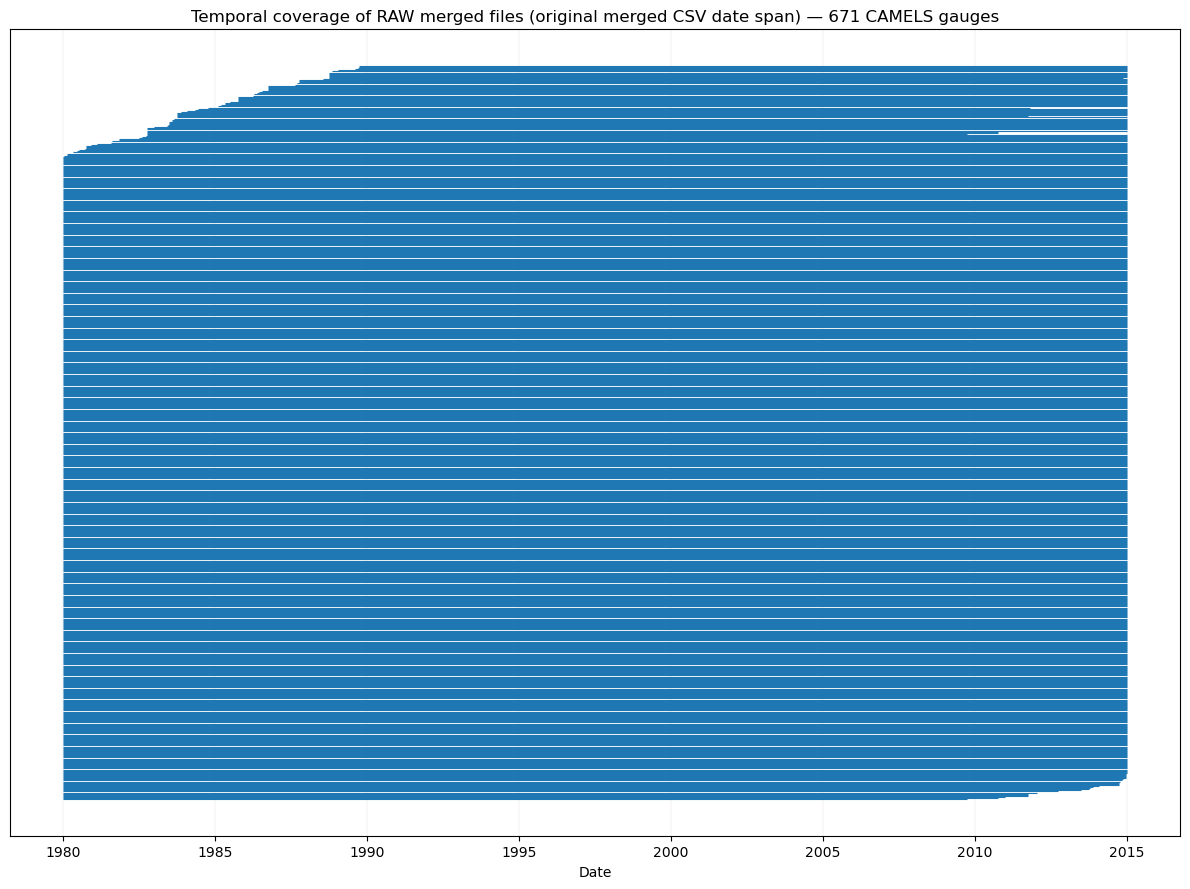

Saved plot: Q_temporal_ranges_all671_rawfile.png
Basins plotted: 671 / 671


In [69]:
IN_DIR = OUT_ROOT / "merged_csv"

out_csv = SUMMARY_DIR / "Q_temporal_ranges_all671_rawfile.csv"
out_png = PDF_DIR / "Q_temporal_ranges_all671_rawfile.png"

rows = []
files = sorted(IN_DIR.glob("*_merged_forcing_q.csv"))

for f in files:
    gid = f.name.split("_")[0]
    df = pd.read_csv(f)

    if len(df) == 0:
        rows.append([gid, pd.NaT, pd.NaT, 0])
    else:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.sort_values("Date")

        rows.append([gid, df["Date"].min(), df["Date"].max(), len(df)])

ranges = pd.DataFrame(rows, columns=["gauge_id", "data_start", "data_end", "n_rows"])
ranges.to_csv(out_csv, index=False)
print("Saved CSV:", out_csv.name)

ranges2 = ranges.dropna(subset=["data_start", "data_end"]).sort_values(
    ["data_start", "data_end"]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 9))
y = np.arange(len(ranges2))

ax.hlines(y, ranges2["data_start"], ranges2["data_end"], linewidth=0.8)

ax.set_yticks([])
ax.set_xlabel("Date")
ax.set_title("Temporal coverage of RAW merged files (original merged CSV date span) — 671 CAMELS gauges")

ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="x", linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.savefig(out_png, dpi=250)
plt.show()

print("Saved plot:", out_png.name)
print("Basins plotted:", len(ranges2), "/", len(ranges))

## Basin-to-basin comparison of TE (671 basins)

In this step, I summarize how Transfer Entropy (TE) varies from basin to basin using the all-basin TE results table (671 basins × 4 forcings × 30 lags).

### What I compute
For each basin and each forcing (PRCP, SRAD, Tair, VP), I find:
- **Peak TE** = the maximum TE value across lags τ = 1–30  
- **Peak lag** = the lag τ where TE is maximum

Then, for each basin, I define the **dominant forcing** as the forcing with the largest **Peak TE** among the four forcings.

### What I report
- The number of basins where each forcing is the dominant forcing  
- The distribution of **peak lag** for the dominant forcing across all basins

This provides a simple basin-to-basin comparison of:
1) which forcing tends to carry the strongest information to streamflow, and  
2) whether the strongest information transfer happens at short vs long lags.

In [70]:
te = pd.read_csv(SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv")
te["gauge_id"] = te["gauge_id"].astype(str).str.zfill(8)

# 1) Peak TE and peak lag per basin x forcing
idx = te.groupby(["gauge_id","Source"])["TE_nats"].idxmax()
peak = te.loc[idx, ["gauge_id","huc_02","Source","Lag","TE_nats"]].rename(
    columns={"Lag":"peak_lag","TE_nats":"peak_TE"}
)

# 2) Dominant forcing per basin (largest peak_TE among the 4 forcings)
idx2 = peak.groupby("gauge_id")["peak_TE"].idxmax()
dominant = peak.loc[idx2, ["gauge_id","Source","peak_lag","peak_TE"]].rename(
    columns={"Source":"dominant_forcing"}
)

print("Dominant forcing counts:")
print(dominant["dominant_forcing"].value_counts())

print("\nPeak lag distribution (dominant forcing):")
print(dominant["peak_lag"].value_counts().sort_index())

# Optional: quick table to inspect
display(dominant.head())

Dominant forcing counts:
dominant_forcing
PRCP    388
SRAD    157
Tair     95
VP       31
Name: count, dtype: int64

Peak lag distribution (dominant forcing):
peak_lag
1     458
2      56
3      16
4       3
5       4
6       3
7       4
8       5
9       2
10      1
11      4
12      8
13      4
14      7
15      4
16      4
17      4
18      2
19      6
20      1
21      3
22      4
23      7
24     10
25     11
26     13
27      7
28      9
29      6
30      5
Name: count, dtype: int64


,gauge_id,dominant_forcing,peak_lag,peak_TE
73,01013500,Tair,14,0.004888
120,01022500,PRCP,1,0.016681
240,01030500,PRCP,1,0.013428
360,01031500,PRCP,1,0.003859
480,01047000,PRCP,1,0.002277


Across the 671 CAMELS basins, precipitation (PRCP) is the dominant forcing in the largest share of basins (389), followed by SRAD (156), Tair (95), and VP (31), meaning that in most basins precipitation carries the strongest information about streamflow, while a substantial subset shows stronger information transfer from energy-related variables (especially SRAD and Tair), likely reflecting seasonal/energy control and storage–evapotranspiration influences. The peak-lag distribution for the dominant forcing is strongly concentrated at short lags, with most basins peaking at lag 1 day (459 basins) and far fewer peaking at lag 2 (56) or lag 3 (16), indicating that the strongest forcing→Q information transfer typically occurs with a rapid daily response, while the smaller number of basins with longer peak lags suggests delayed hydrologic response due to buffering and memory (e.g., storage/baseflow, snow/soil/groundwater processes).

## Dominant forcing × peak-lag distribution (basin-to-basin summary)

Here I break down the basin-to-basin TE results in more detail.

For each basin, I already identified:
- **dominant_forcing** = the forcing with the maximum TE (over τ = 1–30)
- **peak_lag** = the lag τ where that maximum TE occurs

Now I summarize, for each dominant forcing separately (PRCP, SRAD, Tair, VP), how the basins are distributed across peak lags τ = 1–30.  
This answers questions like: *Among the basins dominated by PRCP, how many peak at lag 1 vs lag 2 vs … lag 30?* and similarly for SRAD/Tair/VP.

In [71]:
# dominant forcing × peak lag counts
tab = pd.crosstab(dominant["dominant_forcing"], dominant["peak_lag"])

# Ensure columns 1..30 exist (even if some missing)
tab = tab.reindex(columns=range(1,31), fill_value=0)

# add row totals
tab["Total"] = tab.sum(axis=1)

display(tab)

peak_lag,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,Total
dominant_forcing,,,,,,,,,,,,,,,,,,,,,
PRCP,362,19,5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,388
SRAD,74,35,11,0,2,1,1,3,2,0,...,1,0,3,3,3,0,2,1,1,157
Tair,13,1,0,0,1,2,2,1,0,1,...,3,7,5,7,10,6,6,3,3,95
VP,9,1,0,2,1,0,1,1,0,0,...,0,0,2,1,0,1,1,2,1,31


In [72]:
tab_pct = tab.loc[:, 1:30].div(tab["Total"], axis=0) * 100
tab_pct = tab_pct.round(1)
display(tab_pct)

peak_lag,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
dominant_forcing,,,,,,,,,,,,,,,,,,,,,
PRCP,93.3,4.9,1.3,0.3,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRAD,47.1,22.3,7.0,0.0,1.3,0.6,0.6,1.9,1.3,0.0,...,1.3,0.6,0.0,1.9,1.9,1.9,0.0,1.3,0.6,0.6
Tair,13.7,1.1,0.0,0.0,1.1,2.1,2.1,1.1,0.0,1.1,...,1.1,3.2,7.4,5.3,7.4,10.5,6.3,6.3,3.2,3.2
VP,29.0,3.2,0.0,6.5,3.2,0.0,3.2,3.2,0.0,0.0,...,0.0,0.0,0.0,6.5,3.2,0.0,3.2,3.2,6.5,3.2


## Dominant forcing × peak lag heatmap (counts across 671 basins)

This figure summarizes basin-to-basin variability in Transfer Entropy (TE) in a compact way. For each basin, I first identify the **dominant forcing** (the forcing with the maximum TE across lags τ = 1–30). I also record the **peak lag** (the lag τ where that maximum TE occurs). The heatmap then counts how many basins fall into each (dominant forcing, peak lag) combination. This helps reveal whether the strongest forcing→streamflow information transfer tends to occur at short lags or long lags, and how this pattern differs depending on which forcing dominates (PRCP vs SRAD vs Tair vs VP).

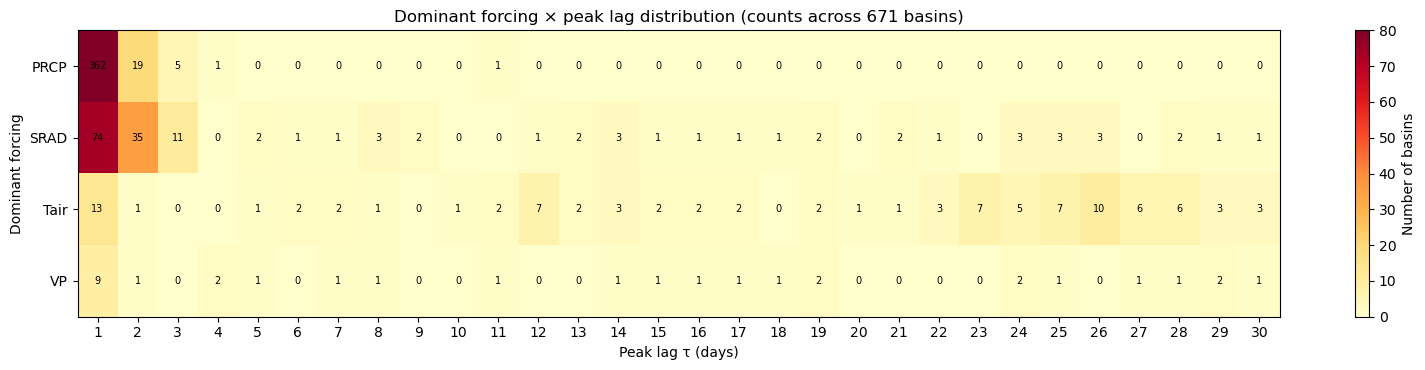

In [73]:
# dominant has columns: dominant_forcing, peak_lag
tab = pd.crosstab(dominant["dominant_forcing"], dominant["peak_lag"])
tab = tab.reindex(columns=range(1, 31), fill_value=0)   # ensure 1..30 columns exist
tab = tab.reindex(index=["PRCP","SRAD","Tair","VP"])  

fig, ax = plt.subplots(figsize=(16, 3.8))

im = ax.imshow(tab.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=80)

ax.set_title("Dominant forcing × peak lag distribution (counts across 671 basins)")
ax.set_xlabel("Peak lag τ (days)")
ax.set_ylabel("Dominant forcing")

# ticks
ax.set_xticks(np.arange(30))
ax.set_xticklabels(range(1, 31))
ax.set_yticks(np.arange(tab.shape[0]))
ax.set_yticklabels(tab.index)

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of basins")

# annotate counts in each cell
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        ax.text(j, i, str(tab.values[i, j]), ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

Across 671 basins, the heatmap shows a strong concentration at very short lags, especially for precipitation-dominated basins: most PRCP-dominant basins peak at lag 1, and only a small fraction peak at lag 2–3, with almost none at longer lags. SRAD-dominant basins are more spread across lags, but still weighted toward early response (lags 1–3) with smaller counts appearing at many intermediate and longer lags. In contrast, Tair-dominant basins show a noticeably broader distribution, including a cluster of basins peaking at longer lags (roughly in the 20s), suggesting delayed or memory-driven influences where temperature/energy-related variability carries information to streamflow over longer timescales. VP-dominant basins are few overall and scattered across lags, indicating that vapor pressure is rarely the strongest information source and does not show a single dominant lag pattern compared to PRCP and SRAD.

## Save basin-to-basin TE summary CSVs

In this step, I save the key basin-to-basin summary tables for later analysis:
- dominant forcing per basin
- dominant forcing + peak lag + peak TE per basin
- peak TE per basin for each forcing (PRCP/SRAD/Tair/VP)
- a clean “basin-to-basin dominant forcing” table for quick plotting and grouping

In [74]:
# Folder to save summary CSVs
OUT_SUM = SUMMARY_DIR
OUT_SUM.mkdir(parents=True, exist_ok=True)

# 1) dominant_forcing_per_basin.csv
# minimal: gauge_id + dominant forcing
dominant_forcing_per_basin = dominant[["gauge_id", "dominant_forcing"]].copy()
path1 = OUT_SUM / "dominant_forcing_per_basin.csv"
dominant_forcing_per_basin.to_csv(path1, index=False)
print("Saved:", path1)

# 2) TE_dominant_forcing_per_basin.csv
# includes peak lag and peak TE for the dominant forcing
TE_dominant_forcing_per_basin = dominant[["gauge_id", "dominant_forcing", "peak_lag", "peak_TE"]].copy()
path2 = OUT_SUM / "TE_dominant_forcing_per_basin.csv"
TE_dominant_forcing_per_basin.to_csv(path2, index=False)
print("Saved:", path2)

# 3) dominant_te_per_basin.csv
# peak TE per forcing for each basin (wide format: columns PRCP/SRAD/Tair/VP)
# peak dataframe should have: gauge_id, Source, peak_TE, peak_lag (at least)
dominant_te_per_basin = peak.pivot(index="gauge_id", columns="Source", values="peak_TE").reset_index()
dominant_te_per_basin.columns.name = None
path3 = OUT_SUM / "dominant_te_per_basin.csv"
dominant_te_per_basin.to_csv(path3, index=False)
print("Saved:", path3)

# 4) basin_to_basin_dominant_forcing.csv
# clean combined table: dominant forcing + also include peak TE per each forcing (optional but useful)
basin_to_basin_dominant_forcing = dominant.merge(dominant_te_per_basin, on="gauge_id", how="left")

path4 = OUT_SUM / "basin_to_basin_dominant_forcing.csv"
basin_to_basin_dominant_forcing.to_csv(path4, index=False)
print("Saved:", path4)

# quick check
display(basin_to_basin_dominant_forcing.head())

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\dominant_forcing_per_basin.csv
Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\TE_dominant_forcing_per_basin.csv
Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\dominant_te_per_basin.csv
Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv\basin_to_basin_dominant_forcing.csv


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP
0,01013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685
1,01022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192
2,01030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949
3,01031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597
4,01047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330


In [75]:
print("SUMMARY_DIR =", SUMMARY_DIR)
print("LOG_DIR =", LOG_DIR)
print("OUT_ROOT =", OUT_ROOT)

SUMMARY_DIR = C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv
LOG_DIR = C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\logs
OUT_ROOT = C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs


In [57]:
for f in os.listdir(SUMMARY_DIR):
    print(f)

AllBasins_DataDateRanges.csv
basin_to_basin_dominant_forcing.csv
dominant_forcing_per_basin.csv
dominant_te_per_basin.csv
Probability_Distributions_Summary.csv
Q_cleaning_summary_from_raw_all671.csv
Q_clean_continuity_check_all671.csv
Q_temporal_ranges_all671.csv
Q_temporal_ranges_all671_cleanQ.csv
Q_temporal_ranges_all671_rawfile.csv
TE_AllBasins_tau1_30_PRCPspecial_bins5.csv
TE_dominant_forcing_per_basin.csv
TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv
TimeSeries_DateRanges_All671.csv
TimeSeries_DateRanges_AllYEAR_All671.csv


In [76]:
te_path = SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv"
print("Exists:", te_path.exists())

if te_path.exists():
    te_df = pd.read_csv(te_path)
    print("Rows:", len(te_df))
    print("Columns:", te_df.columns.tolist())
    display(te_df.head())

Exists: True
Rows: 80520
Columns: ['gauge_id', 'huc_02', 'Source', 'Target', 'Bins', 'Lag', 'TE_nats']


,gauge_id,huc_02,Source,Target,Bins,Lag,TE_nats
0,1013500,1,PRCP,Q,5,1,0.002761
1,1013500,1,PRCP,Q,5,2,0.001754
2,1013500,1,PRCP,Q,5,3,0.001439
3,1013500,1,PRCP,Q,5,4,0.000913
4,1013500,1,PRCP,Q,5,5,0.001240


In [77]:
log_path = LOG_DIR / "TE_AllBasins_log.csv"
log_df = pd.read_csv(log_path)

print(log_df.head())
print()
print(log_df["status"].value_counts(dropna=False))
print()
print(log_df["info"].dropna().head(20).tolist())

   gauge_id  huc_02 status  n_points_window  info
0   1013500       1     OK            12784   NaN
1   1022500       1     OK            12784   NaN
2   1030500       1     OK            12784   NaN
3   1031500       1     OK            12784   NaN
4   1047000       1     OK            12784   NaN

status
OK    671
Name: count, dtype: int64

[]


## Shuffle test for Transfer Entropy (TE) for all 671 CAMELS basins

In this step, I apply the same shuffle-test logic used for the single-basin TE analysis to all 671 CAMELS basins.

For each basin, each forcing (PRCP, SRAD, Tair, VP), and each lag \(tau = 1,2,,......,30):

1. Compute the observed TE from forcing \(X\) to streamflow \(Q\).
2. Shuffle the source series \(X\) many times while keeping \(Q\) unchanged.
3. Recompute TE for each shuffled series to form the null distribution.
4. Compute the 95th percentile of the shuffled TE values.
5. Compute the shuffle-test p-value.
6. Mark the observed TE as significant if it is greater than the 95th percentile.

This gives a basin-wise significance test of TE and helps distinguish meaningful information transfer from values that may arise by chance.

In [78]:
# SHUFFLE TEST FOR TE: ALL 671 CAMELS BASINS
# Same logic as single-basin shuffle test

USE_CUSTOM_DATES = False
CUSTOM_START = "1985-01-01"
CUSTOM_END   = "2009-12-31"

NBINS = 5
LAGS = range(1, 31)
SFL = 200
MIN_POINTS = 50

pairs = [("PRCP", "Q"), ("SRAD", "Q"), ("Tair", "Q"), ("VP", "Q")]

shuffle_csv = SUMMARY_DIR / "TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv"
shuffle_log_csv = LOG_DIR / "TE_shuffle_all671_log.csv"

start_date = pd.to_datetime(CUSTOM_START)
end_date   = pd.to_datetime(CUSTOM_END)

shuffle_results = []
shuffle_log_rows = []


def shuffle_test_te_full(x, y, bins, lag, sfl=200, rng=None, base=np.e):
    """
    Same shuffle-test logic as single-basin version.

    Returns:
        te_obs  : observed TE
        thr95   : 95th percentile of shuffled TE
        pval    : shuffle-test p-value
        sig     : True if te_obs > thr95
    """
    if rng is None:
        rng = np.random.default_rng(0)

    te_obs = transfer_entropy(x, y, bins=bins, base=base, lag=lag)

    te_null = np.zeros(sfl)
    for i in range(sfl):
        x_shuff = x.copy()
        rng.shuffle(x_shuff)

        te_null[i] = transfer_entropy(
            x_shuff, y,
            bins=bins,
            base=base,
            lag=lag
        )

    thr95 = np.quantile(te_null, 0.95)
    pval  = (np.sum(te_null >= te_obs) + 1) / (sfl + 1)
    sig   = te_obs > thr95

    return te_obs, thr95, pval, sig


for i, row in gauge_df.iterrows():

    gauge_id = str(row["gauge_id"]).zfill(8)
    huc02    = row["huc_02"]

    try:
        csv_path = (OUT_ROOT / "merged_csv") / f"{gauge_id}_merged_forcing_q.csv"
        df = pd.read_csv(csv_path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

        # make variables numeric
        for col in ["PRCP", "SRAD", "Tair", "VP", "Q"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # keep PRCP = 0, remove only invalid negative precipitation values
        df.loc[df["PRCP"] < 0, "PRCP"] = np.nan

        # remove invalid negative Q values like -999
        df.loc[df["Q"] < 0, "Q"] = np.nan

        # optional date filter
        if USE_CUSTOM_DATES:
            df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

        if len(df) == 0:
            shuffle_log_rows.append([gauge_id, huc02, "NO DATA", 0, "empty after date filter"])
            continue

        # basin-specific PRCP edges
        prcp_edges = prcp_special_bins_exact(df["PRCP"], nb_total=NBINS)

        for source_var, target_var in pairs:

            x_all = df[source_var].values
            y_all = df[target_var].values

            # keep original daily alignment; do NOT remove rows before lagging
            x_use = x_all
            y_use = y_all

            for lag in LAGS:

                if len(x_use) <= lag or len(y_use) <= lag or len(x_use) < MIN_POINTS:
                    te_obs = np.nan
                    thr95  = np.nan
                    pval   = np.nan
                    sig    = False
                else:
                    rng = np.random.default_rng(1000 + i * 100 + lag)

                    te_obs, thr95, pval, sig = shuffle_test_te_full(
                        x_use,
                        y_use,
                        bins=te_bins_for(source_var, NBINS),
                        lag=lag,
                        sfl=SFL,
                        rng=rng,
                        base=np.e
                    )

                shuffle_results.append([
                    gauge_id, huc02,
                    source_var, target_var,
                    NBINS, lag,
                    te_obs, thr95, pval, sig
                ])

        shuffle_log_rows.append([gauge_id, huc02, "OK", len(df), ""])

        if (i + 1) % 20 == 0:
            print("Done basins:", i + 1, "/ 671")

    except Exception as e:
        shuffle_log_rows.append([gauge_id, huc02, "FAIL", np.nan, str(e)])
        print("FAIL:", gauge_id, "|", e)


# save results
shuffle_df = pd.DataFrame(
    shuffle_results,
    columns=[
        "gauge_id", "huc_02", "Source", "Target", "Bins", "Lag",
        "TE_obs", "thr95", "pval", "sig"
    ]
)
shuffle_df.to_csv(shuffle_csv, index=False)

shuffle_log_df = pd.DataFrame(
    shuffle_log_rows,
    columns=["gauge_id", "huc_02", "status", "n_points_window", "info"]
)
shuffle_log_df.to_csv(shuffle_log_csv, index=False)

print("Saved shuffle CSV:", shuffle_csv.name)
print("Saved shuffle log CSV:", shuffle_log_csv.name)
print(shuffle_log_df["status"].value_counts(dropna=False))

display(shuffle_df.head())

Done basins: 20 / 671
Done basins: 40 / 671
Done basins: 60 / 671
Done basins: 80 / 671
Done basins: 100 / 671
Done basins: 120 / 671
Done basins: 140 / 671
Done basins: 160 / 671
Done basins: 180 / 671
Done basins: 200 / 671
Done basins: 220 / 671
Done basins: 240 / 671
Done basins: 260 / 671
Done basins: 280 / 671
Done basins: 300 / 671
Done basins: 320 / 671
Done basins: 340 / 671
Done basins: 360 / 671
Done basins: 380 / 671
Done basins: 400 / 671
Done basins: 420 / 671
Done basins: 440 / 671
Done basins: 460 / 671
Done basins: 480 / 671
Done basins: 500 / 671
Done basins: 520 / 671
Done basins: 540 / 671
Done basins: 560 / 671
Done basins: 580 / 671
Done basins: 600 / 671
Done basins: 620 / 671
Done basins: 640 / 671
Done basins: 660 / 671
Saved shuffle CSV: TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv
Saved shuffle log CSV: TE_shuffle_all671_log.csv
status
OK    671
Name: count, dtype: int64


,gauge_id,huc_02,Source,Target,Bins,Lag,TE_obs,thr95,pval,sig
0,01013500,01,PRCP,Q,5,1,0.002761,0.001187,0.004975,True
1,01013500,01,PRCP,Q,5,2,0.001754,0.001171,0.004975,True
2,01013500,01,PRCP,Q,5,3,0.001439,0.001204,0.009950,True
3,01013500,01,PRCP,Q,5,4,0.000913,0.001174,0.258706,False
4,01013500,01,PRCP,Q,5,5,0.001240,0.001064,0.024876,True


## PDF heatmaps for shuffle-test filtered TE for all 671 basins

In this step, I create one heatmap page per basin using the basin-wise shuffle-test results.

For each basin, forcing, and lag:
- keep the observed TE value if it is significant after the shuffle test
- replace non-significant TE values with NaN

This produces a 671-page PDF in which each page shows only statistically significant TE patterns from atmospheric forcings to streamflow.

In [79]:
# Read shuffle-test results
shuffle_path = SUMMARY_DIR / "TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv"
shuffle_df = pd.read_csv(shuffle_path)

# Standardize gauge_id format
shuffle_df["gauge_id"] = shuffle_df["gauge_id"].astype(str).str.zfill(8)
gauge_df["gauge_id"] = gauge_df["gauge_id"].astype(str).str.zfill(8)

# Build metadata map
meta_map = gauge_df.set_index("gauge_id")[["huc_02", "gauge_name"]].to_dict("index")

# Keep only significant TE values; non-significant becomes NaN
shuffle_df["TE_sig"] = np.where(shuffle_df["sig"] == True, shuffle_df["TE_obs"], np.nan)

# Fixed row order
source_order = ["PRCP", "SRAD", "Tair", "VP"]

#Save PDF 
pdf_path = PDF_DIR / "TE_Shuffle_Significant_Heatmaps_All671.pdf"

with PdfPages(pdf_path) as pdf:

    basin_ids = sorted(shuffle_df["gauge_id"].unique())

    for i, gid in enumerate(basin_ids, start=1):
        sub = shuffle_df[shuffle_df["gauge_id"] == gid].copy()

        # Force row order
        sub["Source"] = pd.Categorical(sub["Source"], categories=source_order, ordered=True)

        # Create 4 x 30 matrix
        mat = sub.pivot(index="Source", columns="Lag", values="TE_sig")
        mat = mat.reindex(index=source_order, columns=range(1, 31))

        # Metadata
        huc02 = meta_map.get(gid, {}).get("huc_02", "")
        gauge_name = meta_map.get(gid, {}).get("gauge_name", "Unknown Gauge")

        # Plot
        fig, ax = plt.subplots(figsize=(16, 4.8))

        cmap = plt.cm.viridis.copy()
        cmap.set_bad(color="white")   # blank fill for non-significant cells

        sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            annot=True,
            fmt=".4f",
            linewidths=0.5,
            linecolor="lightgray",
            mask=mat.isna(),
            cbar_kws={"label": "Significant TE (nats)"},
            annot_kws={"size": 7}
        )

        # Draw full grid borders so blank cells still appear as boxes
        nrows, ncols = mat.shape
        for x in range(ncols + 1):
            ax.axvline(x, color="lightgray", lw=0.5)
        for y in range(nrows + 1):
            ax.axhline(y, color="lightgray", lw=0.5)

        ax.set_title(
            f"Shuffle-Test Significant TE to Streamflow — Basin {gid} (HUC {huc02}) — {gauge_name}"
        )
        ax.set_xlabel("Lag τ (days)")
        ax.set_ylabel("Atmospheric Forcing")

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        if i % 50 == 0:
            print(f"Saved pages: {i} / {len(basin_ids)}")

print("Saved PDF:", pdf_path)

Saved pages: 50 / 671
Saved pages: 100 / 671
Saved pages: 150 / 671
Saved pages: 200 / 671
Saved pages: 250 / 671
Saved pages: 300 / 671
Saved pages: 350 / 671
Saved pages: 400 / 671
Saved pages: 450 / 671
Saved pages: 500 / 671
Saved pages: 550 / 671
Saved pages: 600 / 671
Saved pages: 650 / 671
Saved PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf\TE_Shuffle_Significant_Heatmaps_All671.pdf


In [80]:
print("Expected pages:", shuffle_df["gauge_id"].nunique())

Expected pages: 671


## Comparison of TE and shuffle-test significant TE for all 671 basins

In this step, I create a comparison PDF with one page per basin.

For each basin:
- the top heatmap shows the original TE from atmospheric forcings to streamflow
- the bottom heatmap shows only the TE values that remain significant after the shuffle test

This side-by-side layout makes it easier to compare the full TE pattern with the statistically significant TE pattern for the same basin.

In [81]:
print(pd.read_csv(SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv").shape)
print(pd.read_csv(SUMMARY_DIR / "TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv").shape)

(80520, 7)
(80520, 10)


In [82]:
# COMPARISON PDF: ORIGINAL TE vs SHUFFLE-SIGNIFICANT TE
# SAME COLOR SCALE for both panels within each basin

# Read TE results
te_path = SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv"
te_df = pd.read_csv(te_path)

# Read shuffle-test results
shuffle_path = SUMMARY_DIR / "TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv"
shuffle_df = pd.read_csv(shuffle_path)

# Standardize gauge_id format
te_df["gauge_id"] = te_df["gauge_id"].astype(str).str.zfill(8)
shuffle_df["gauge_id"] = shuffle_df["gauge_id"].astype(str).str.zfill(8)
gauge_df["gauge_id"] = gauge_df["gauge_id"].astype(str).str.zfill(8)

# Metadata map
meta_map = gauge_df.set_index("gauge_id")[["huc_02", "gauge_name"]].to_dict("index")

# Keep only significant TE in shuffle results
shuffle_df["TE_sig"] = np.where(shuffle_df["sig"] == True, shuffle_df["TE_obs"], np.nan)

# Fixed source order
source_order = ["PRCP", "SRAD", "Tair", "VP"]

# Output PDF
pdf_path = PDF_DIR / "TE_vs_ShuffleSignificant_Heatmaps_All671.pdf"

# Basin list from TE file
basin_ids = sorted(te_df["gauge_id"].unique())

with PdfPages(pdf_path) as pdf:

    for i, gid in enumerate(basin_ids, start=1):

        # Subset one basin
        te_sub = te_df[te_df["gauge_id"] == gid].copy()
        sh_sub = shuffle_df[shuffle_df["gauge_id"] == gid].copy()

        te_sub["Source"] = pd.Categorical(te_sub["Source"], categories=source_order, ordered=True)
        sh_sub["Source"] = pd.Categorical(sh_sub["Source"], categories=source_order, ordered=True)

        te_sub = te_sub.sort_values(["Source", "Lag"])
        sh_sub = sh_sub.sort_values(["Source", "Lag"])

        # Pivot to matrices
        te_mat = te_sub.pivot(index="Source", columns="Lag", values="TE_nats")
        te_mat = te_mat.reindex(index=source_order, columns=range(1, 31))

        sh_mat = sh_sub.pivot(index="Source", columns="Lag", values="TE_sig")
        sh_mat = sh_mat.reindex(index=source_order, columns=range(1, 31))

        # Shared color scale per basin
        te_vals = te_mat.to_numpy().astype(float)
        sh_vals = sh_mat.to_numpy().astype(float)

        combined = np.concatenate([
            te_vals[np.isfinite(te_vals)],
            sh_vals[np.isfinite(sh_vals)]
        ])

        if len(combined) == 0:
            vmin, vmax = 0.0, 1.0
        else:
            vmin = np.nanmin(combined)
            vmax = np.nanmax(combined)
            if vmin == vmax:
                vmax = vmin + 1e-12

        # Metadata
        huc02 = meta_map.get(gid, {}).get("huc_02", "")
        gauge_name = meta_map.get(gid, {}).get("gauge_name", "Unknown Gauge")

        # Figure with 2 panels
        fig, axes = plt.subplots(
            nrows=2, ncols=1,
            figsize=(16, 9),
            constrained_layout=True
        )

        # Top: Original TE
        sns.heatmap(
            te_mat,
            ax=axes[0],
            cmap="viridis",
            annot=True,
            fmt=".4f",
            linewidths=0.3,
            vmin=vmin,
            vmax=vmax,
            cbar_kws={"label": "TE (nats)"},
            annot_kws={"size": 7}
        )
        axes[0].set_title(
            f"Original TE to Streamflow — Basin {gid} (HUC {huc02}) — {gauge_name}"
        )
        axes[0].set_xlabel("Lag τ (days)")
        axes[0].set_ylabel("Atmospheric Forcing")

        # Bottom: Shuffle-significant TE
        cmap2 = plt.cm.viridis.copy()
        cmap2.set_bad(color="white")

        sns.heatmap(
            sh_mat,
            ax=axes[1],
            cmap=cmap2,
            annot=True,
            fmt=".4f",
            linewidths=0.5,
            linecolor="lightgray",
            mask=sh_mat.isna(),
            vmin=vmin,
            vmax=vmax,
            cbar_kws={"label": "Significant TE (nats)"},
            annot_kws={"size": 7}
        )

        # Draw full grid so blank cells still show box borders
        nrows, ncols = sh_mat.shape
        for x in range(ncols + 1):
            axes[1].axvline(x, color="lightgray", lw=0.5)
        for y in range(nrows + 1):
            axes[1].axhline(y, color="lightgray", lw=0.5)

        axes[1].set_title(
            f"Shuffle-Test Significant TE to Streamflow — Basin {gid} (HUC {huc02}) — {gauge_name}"
        )
        axes[1].set_xlabel("Lag τ (days)")
        axes[1].set_ylabel("Atmospheric Forcing")

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        if i % 50 == 0:
            print(f"Saved pages: {i} / {len(basin_ids)}")

print("Saved PDF:", pdf_path)

Saved pages: 50 / 671
Saved pages: 100 / 671
Saved pages: 150 / 671
Saved pages: 200 / 671
Saved pages: 250 / 671
Saved pages: 300 / 671
Saved pages: 350 / 671
Saved pages: 400 / 671
Saved pages: 450 / 671
Saved pages: 500 / 671
Saved pages: 550 / 671
Saved pages: 600 / 671
Saved pages: 650 / 671
Saved PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\pdf\TE_vs_ShuffleSignificant_Heatmaps_All671.pdf
